# CA 2.1 - Earthquake Alert Prediction

    magnitude = The magnitude of the earthquake (Richter Scale) 
    depth = The depth where the earthquake begins to rupture (km) 
    cdi = The maximum reported intensity for the event range 
    mmi = The maximum estimated instrumental intensity for the event 
    sig = A comprehensive significance measure determined by multiple factors including magnitude, maximum MMI, felt reports, and estimated impact. Higher values indicate more significant seismic events 
    alert = Categorical earthquake alert level classification system (Target Variable)

An explanation of the dataset was provided on the website from which it was downloaded. The dataset is available here: https://www.kaggle.com/datasets/ahmeduzaki/earthquake-alert-prediction-dataset. According to the information on that website, the dataset focuses primarily on machine learning, which makes it ideal for this assignment.

## QUESTION 1: Import data and relevant libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')

# Display first few rows to verify data loading
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green


All the necessary libraries and the data file were loaded. The first 5 rows were displayed to give a basic idea of what the raw data looks like.

## QUESTION 2: Data Description and EDA

Data Description

Basic Dataset Information
Dataset shape: (1300, 6)
Number of rows: 1300
Number of columns: 6

Column names:
['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'alert']

Data Types
magnitude    float64
depth        float64
cdi          float64
mmi          float64
sig          float64
alert         object
dtype: object

Statistical Summary (Numerical Columns)
         magnitude        depth          cdi          mmi          sig
count  1300.000000  1300.000000  1300.000000  1300.000000  1300.000000
mean      7.061008    50.321538     6.976154     6.939231    -9.749231
std       0.423738   104.348286     2.244875     1.354774    62.245214
min       6.500000     2.000000     0.000000     1.000000  -128.000000
25%       6.700000    12.000000     6.000000     6.000000   -54.000000
50%       7.000000    19.000000     8.000000     7.000000    -7.000000
75%       7.300000    38.000000     8.000000     8.000000    31.000000
max       8.600000   670.000000     9.000000     9.000000   

C:\Users\marti\AppData\Local\Temp\ipykernel_34556\1789309242.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df['magnitude'], df['depth'], df['cdi'], df['mmi'], df['sig']], labels=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])


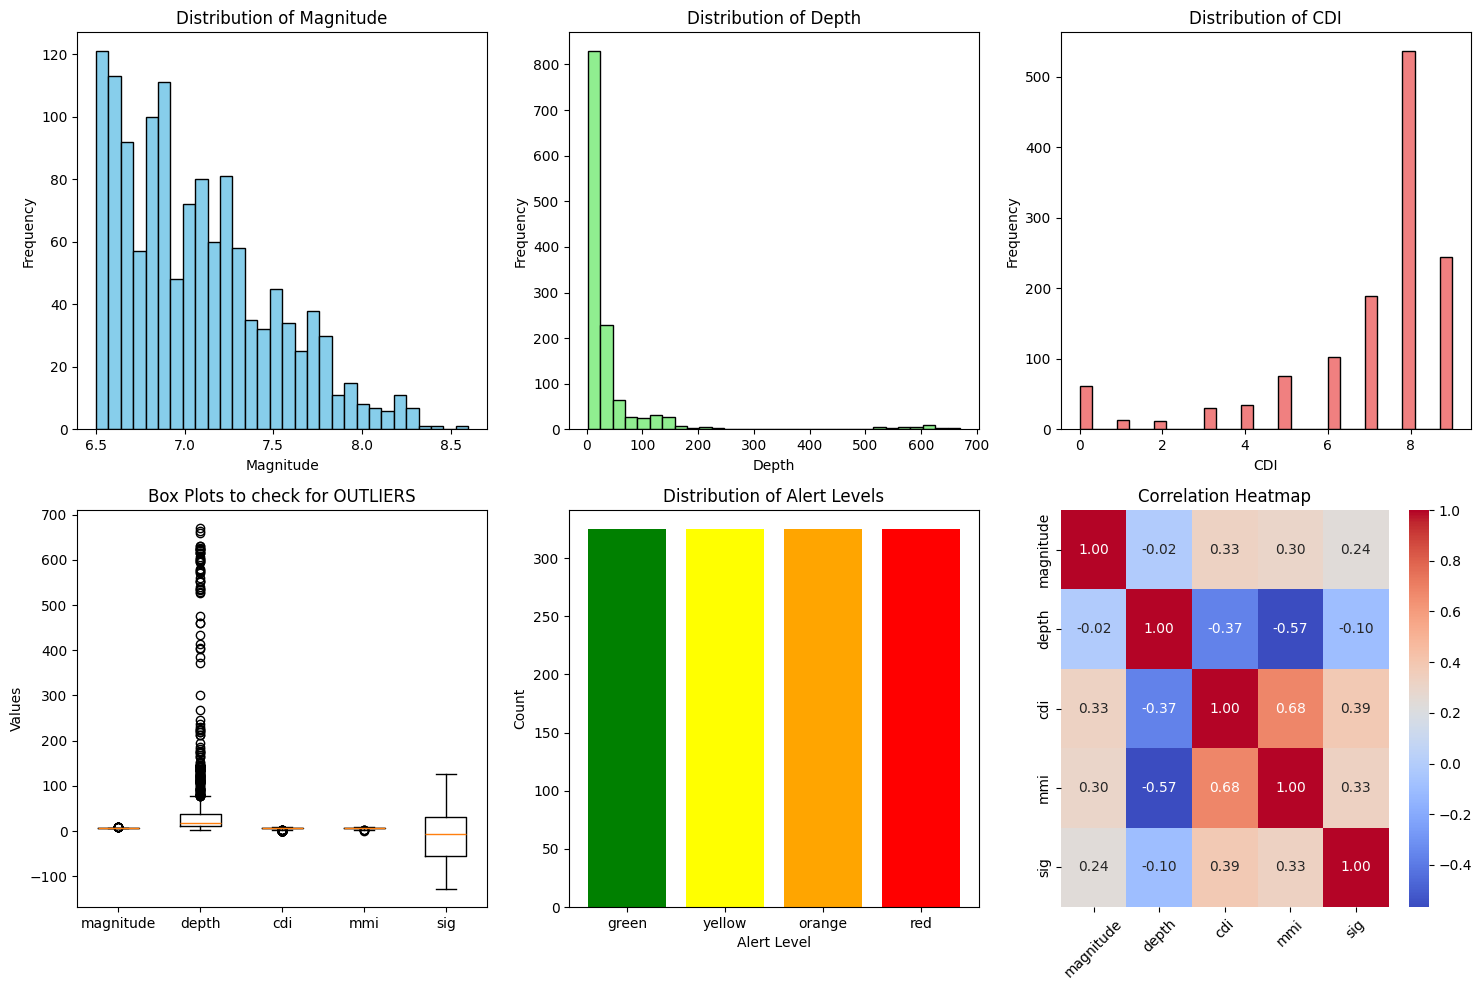

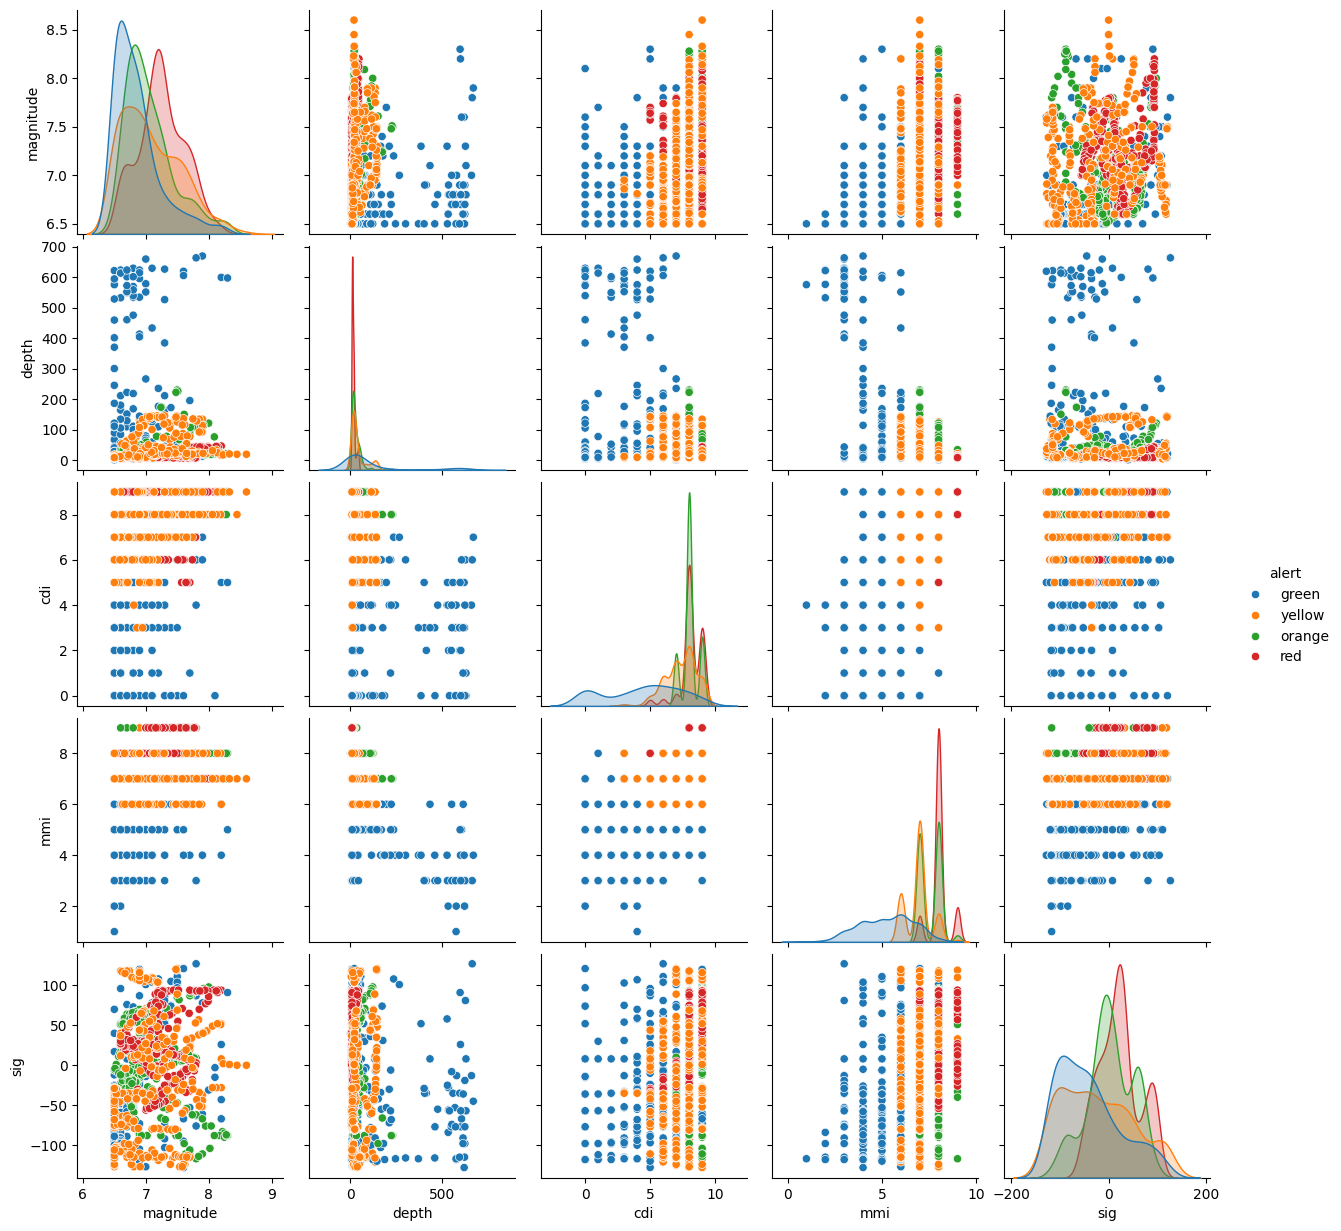

In [2]:
print("Data Description")
# 2.1 Basic information about the dataset
print("\nBasic Dataset Information")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

# 2.2 Data types and info
print("\nData Types")
print(df.dtypes)

# 2.3 Statistical summary
print("\nStatistical Summary (Numerical Columns)")
print(df.describe())

# 2.4 Check for missing values
print("\nMissing Values Check")
print(df.isnull().sum())

# 2.5 Check for duplicates
print("\nDuplicates Check")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# 2.6 Check unique values in target variable
print("\nTarget Variable (alert) Distribution")
print(df['alert'].value_counts())
print(f"\nUnique alert levels: {df['alert'].unique()}")

# 2.7 Visualizations for EDA
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution of numerical features
axes[0, 0].hist(df['magnitude'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Magnitude')
axes[0, 0].set_xlabel('Magnitude')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['depth'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Depth')
axes[0, 1].set_xlabel('Depth')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(df['cdi'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 2].set_title('Distribution of CDI')
axes[0, 2].set_xlabel('CDI')
axes[0, 2].set_ylabel('Frequency')

# Box plots to check outliers
axes[1, 0].boxplot([df['magnitude'], df['depth'], df['cdi'], df['mmi'], df['sig']], labels=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])
axes[1, 0].set_title('Box Plots to check for OUTLIERS')
axes[1, 0].set_ylabel('Values')

# Target variable distribution
alert_counts = df['alert'].value_counts()
axes[1, 1].bar(alert_counts.index, alert_counts.values, color=['green', 'yellow', 'orange', 'red'])
axes[1, 1].set_title('Distribution of Alert Levels')
axes[1, 1].set_xlabel('Alert Level')
axes[1, 1].set_ylabel('Count')

# Correlation heatmap of numerical features
numeric_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
correlation = df[numeric_cols].corr()

# Seaborn heatmap
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], cbar=True)
axes[1, 2].set_xticklabels(numeric_cols, rotation=45)
axes[1, 2].set_yticklabels(numeric_cols)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Pair plot to see relationships
sns.pairplot(df, hue='alert', vars=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])
plt.show()

The dataset contains 1,300 rows and 6 attributes. We found that most data types are numerical, as the dataset itself already suggested. Outliers occurred mainly in the “depth” column. These values appear realistic, which suggests that they should be retained for further modeling. The dataset contains no missing values but includes 44 duplicates. For this dataset, I decided to retain the duplicates because it is possible to achieve the same outcomes. Each alert type (green, yellow, orange, red) contains exactly 325 records. Removing duplicates would therefore lead to class imbalance. Each numerical feature has a different distribution. For example, the depth distribution is right-skewed, with a maximum value of 670, while the magnitude distribution centers around 7.0. The correlation heatmap shows the strongest relationship between cdi and mmi (0.68) and between cdi and sig (0.57). On the other hand, depth and magnitude have an almost zero correlation (0.02), meaning they are not dependent on each other. With the final grid, we can suggest that this dataset is synthetic and designed for use in machine learning models. 

## Data Preprocessing

In [3]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# 1. Encode target variable (alert)
label_encoder = LabelEncoder()
df_processed['alert_encoded'] = label_encoder.fit_transform(df_processed['alert'])
print("\n3. Target Encoding:")
print("Alert level mapping:")
for i, alert_level in enumerate(label_encoder.classes_):
    print(f"   {alert_level} -> {i}")

# 2. Separate features (X) and target (y)
feature_columns = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
X = df_processed[feature_columns]
y = df_processed['alert_encoded']

print(f"\n4. Features selected: {feature_columns}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 3. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Data Split:")
print(f"   Training set size: {X_train.shape[0]} samples")
print(f"   Testing set size: {X_test.shape[0]} samples")

# 4. Scale the features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



3. Target Encoding:
Alert level mapping:
   green -> 0
   orange -> 1
   red -> 2
   yellow -> 3

4. Features selected: ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
Features shape: (1300, 5)
Target shape: (1300,)

5. Data Split:
   Training set size: 1040 samples
   Testing set size: 260 samples


For modeling purposes, I had to convert the categorical alert values into numerical values. Green was assigned a value of 0, orange a value of 1, red a value of 2, and yellow a value of 3. All 5 numerical columns were selected to be features. The final features shape is 1300 rows and 5 columns. The final target shape is 1300 rows and 1 column. The data is divided into 80% training samples and 20% test samples. The StandardScaler tool was used to normalize all features. 

## QUESTION 3: ML Modeling

MODEL 1: Logistic Regression

Logistic Regression Results
Training Accuracy: 0.6423
Testing Accuracy: 0.6654
Precision (weighted): 0.6716
Recall (weighted): 0.6654
F1-Score (weighted): 0.6633

Classification Report (Test Set):
              precision    recall  f1-score   support

       green       0.91      0.78      0.84        65
      orange       0.53      0.42      0.47        65
         red       0.67      0.75      0.71        65
      yellow       0.57      0.71      0.63        65

    accuracy                           0.67       260
   macro avg       0.67      0.67      0.66       260
weighted avg       0.67      0.67      0.66       260



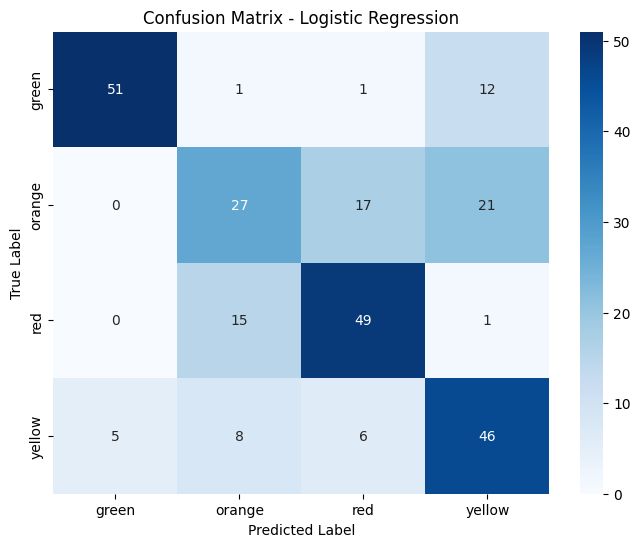

MODEL 2: Decision Tree

Decision Tree Results
Training Accuracy: 1.0000
Testing Accuracy: 0.8885
Precision (weighted): 0.8902
Recall (weighted): 0.8885
F1-Score (weighted): 0.8884

Classification Report (Test Set):
              precision    recall  f1-score   support

       green       0.92      0.85      0.88        65
      orange       0.89      0.85      0.87        65
         red       0.94      0.97      0.95        65
      yellow       0.82      0.89      0.85        65

    accuracy                           0.89       260
   macro avg       0.89      0.89      0.89       260
weighted avg       0.89      0.89      0.89       260



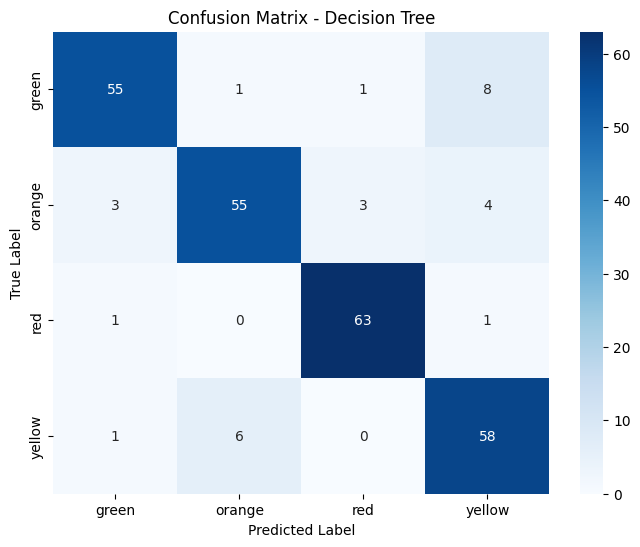

MODEL 3: Random Forest

Random Forest Results
Training Accuracy: 1.0000
Testing Accuracy: 0.9231
Precision (weighted): 0.9292
Recall (weighted): 0.9231
F1-Score (weighted): 0.9239

Classification Report (Test Set):
              precision    recall  f1-score   support

       green       0.98      0.85      0.91        65
      orange       0.94      0.95      0.95        65
         red       0.98      0.97      0.98        65
      yellow       0.81      0.92      0.86        65

    accuracy                           0.92       260
   macro avg       0.93      0.92      0.92       260
weighted avg       0.93      0.92      0.92       260



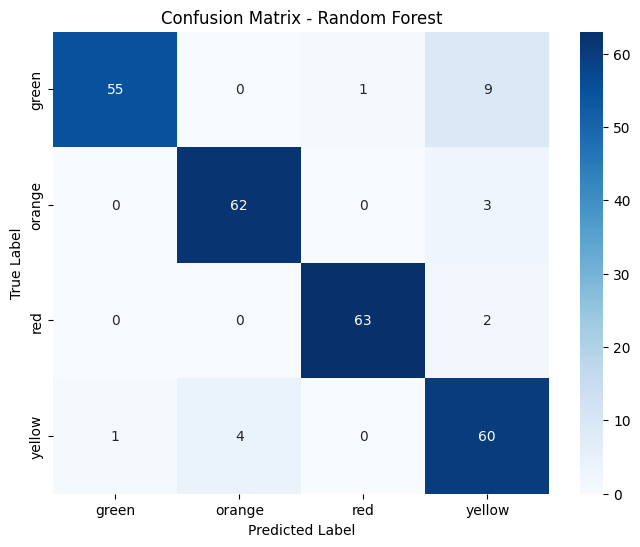

In [4]:
# Create a function to evaluate and compare models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model, return metrics"""
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Calculate other metrics
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"\n{model_name} Results")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")
    
    # Classification Report
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return {'Model': model_name,'Train_Accuracy': train_acc,'Test_Accuracy': test_acc,'Precision': precision,'Recall': recall,'F1_Score': f1}

print("MODEL 1: Logistic Regression")
# Create Logistic Regression model
log_reg_baseline = LogisticRegression(max_iter=1000, random_state=42)
log_results = evaluate_model(log_reg_baseline, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

print("MODEL 2: Decision Tree")
# Create Decision Tree model
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_results = evaluate_model(dt_baseline, X_train, X_test, y_train, y_test, "Decision Tree")

print("MODEL 3: Random Forest")
# Create Random Forest model
rf_baseline = RandomForestClassifier(random_state=42)
rf_results = evaluate_model(rf_baseline, X_train, X_test, y_train, y_test, "Random Forest")

Three models were selected and used. The Random Forest model performed best, achieving an accuracy of 92%. Logistic regression incorrectly classified the color orange as yellow (21 times) and red (17 times). The decision tree performed similarly to the Random Forest model but had a slightly lower accuracy score (88.9%). Therefore, we will choose the Random Forest model for tuning.

## Hyperparameter Tuning


Tuning Random Forest
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.9019
EVALUATING TUNED MODELS

Random Forest (Tuned) Results
Training Accuracy: 1.0000
Testing Accuracy: 0.9231
Precision (weighted): 0.9292
Recall (weighted): 0.9231
F1-Score (weighted): 0.9239

Classification Report (Test Set):
              precision    recall  f1-score   support

       green       0.98      0.85      0.91        65
      orange       0.94      0.95      0.95        65
         red       0.98      0.97      0.98        65
      yellow       0.81      0.92      0.86        65

    accuracy                           0.92       260
   macro avg       0.93      0.92      0.92       260
weighted avg       0.93      0.92      0.92       260



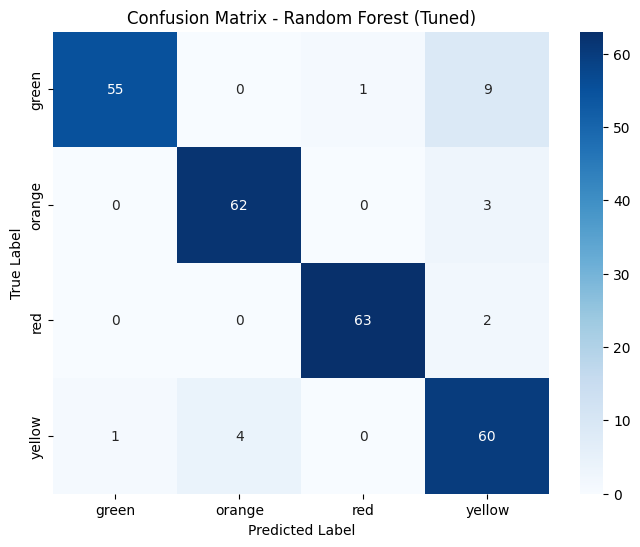

In [5]:
#Tune Random Forest
print("\nTuning Random Forest")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Using a smaller grid for faster execution
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

# Evaluate tuned models
print("EVALUATING TUNED MODELS")
# Tuned Random Forest
tuned_rf_results = evaluate_model(rf_grid.best_estimator_, X_train, X_test, y_train, y_test, "Random Forest (Tuned)")

During the process, we identified the best parameters: max_depth=20, min_samples_leaf=1, min_samples_split=2, and n_estimators=100, with a best cross-validation score of 90.2%. No improvement was observed during tuning. This suggests that the original Random Forest model has already reached its maximum potential.  

## QUESTION 4: Performance Comparison and Report

## Performance Comparison


Performance Comparison Table
                Model  Train_Accuracy  Test_Accuracy  Precision   Recall  F1_Score
  Logistic Regression        0.642308       0.665385   0.671590 0.665385  0.663280
        Decision Tree        1.000000       0.888462   0.890241 0.888462  0.888407
        Random Forest        1.000000       0.923077   0.929181 0.923077  0.923927
Random Forest (Tuned)        1.000000       0.923077   0.929181 0.923077  0.923927


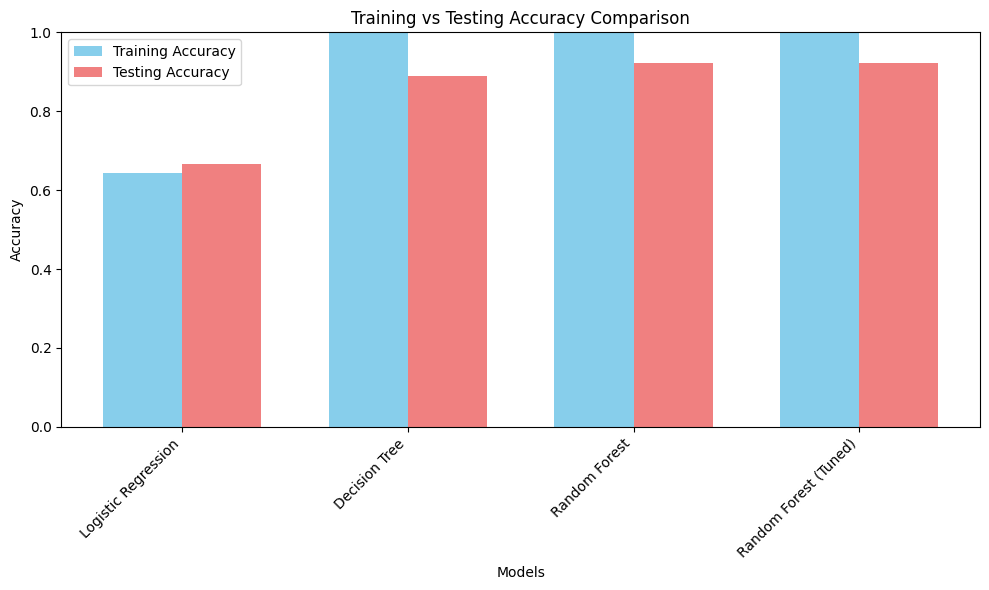

In [6]:
# Create comparison dataframe
results_df = pd.DataFrame([
    log_results,
    dt_results,
    rf_results,
    tuned_rf_results
])

print("\nPerformance Comparison Table")
print(results_df.to_string(index=False))

# Visual comparison - Training vs Testing Accuracy
plt.figure(figsize=(10, 6))

models = results_df['Model'].tolist()
train_acc = results_df['Train_Accuracy'].tolist()
test_acc = results_df['Test_Accuracy'].tolist()

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_acc, width, label='Training Accuracy', color='skyblue')
plt.bar(x + width/2, test_acc, width, label='Testing Accuracy', color='lightcoral')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy Comparison')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

A final performance comparison in which we can assess the difference in accuracy between the individual models both numerically and visually. 

## Report

### Selection of model/models

Logistic Regression, Dicision Three and Random Forest were choosen to play a critical role in this project. Logistic regression was chosen for its simplicity and fast training speed. Decision Tree were selected for their ability to capture nonlinear patterns in the data. Random Forest was choosen to reduce possible overfitting and a combination of multiple decision trees have most of the times better accuracy. 

### Selection of hyper-parameters

The hyperparameters were selected and used primarily for the Random Forest model, as it was the best-performing model out of the three available. The tuning parameters are n_estimators, max_depth, min_samples_split, and min_samples_leaf. These are parameters that should optimize performance.

### Tuning of hyper-parameters

GridSearchCV was used on Random Forest with 5-fold cross-validation. Accuracy for scoring was used because the data are balanced (Each alert level contain 325 samples). This means the accuracy is reliable metric and should be used. Otherwise, if one class would be inbalance, f1 metric would be used. The best hyperparametres for tuning are max_depth: 20, min_samples_leaf: 1, min_samples_split: 2, n_estimators: 100 and the best score for cross-validation is 90.2%. The results were compared, and it was found that there were no differences between them. The original model had already the best possible performance.

### Interpretation of the loss function (if any)

No loss function was used in this project.

### Accuracy of your model during training and testing

                            training accuracy       testing accuracy        idea     
    Logistic Regression:          64.2%                  66.5%          underfitting 
    Decision Tree:                 100%                  88.8%           overfitting 
    Random Forest:                 100%                  92.3%         generalization
    Random Forest (Tuned):         100%                  92.3%            identical  

### Submit the code with the final optimized model


First 5 rows of the dataset:
   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green
Data Description

Basic Dataset Information
Dataset shape: (1300, 6)
Number of rows: 1300
Number of columns: 6

Column names:
['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'alert']

Data Types
magnitude    float64
depth        float64
cdi          float64
mmi          float64
sig          float64
alert         object
dtype: object

Statistical Summary (Numerical Columns)
         magnitude        depth          cdi          mmi          sig
count  1300.000000  1300.000000  1300.000000  1300.000000  1300.000000
mean      7.061008    50.321538     6.976154     6.939231    -9.749231
std       0.423738   104.348286     2.244875     1.354774    62.245214
min       6.500000     2.000000     0.000000     1.00000

C:\Users\marti\AppData\Local\Temp\ipykernel_34556\4199846604.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df['magnitude'], df['depth'], df['cdi'], df['mmi'], df['sig']], labels=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])


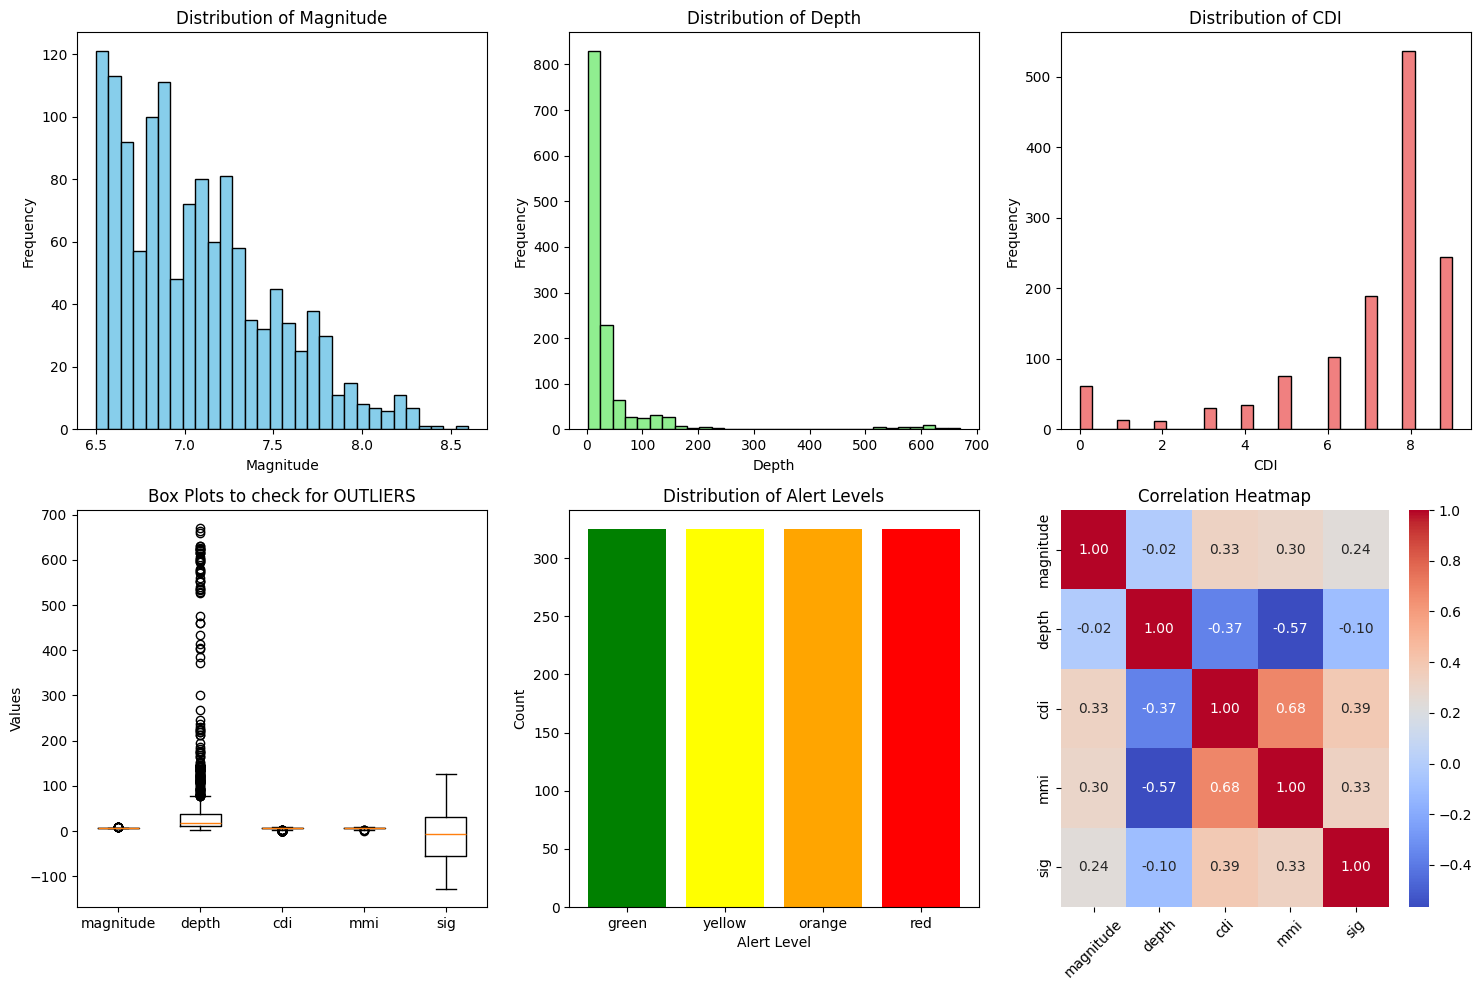

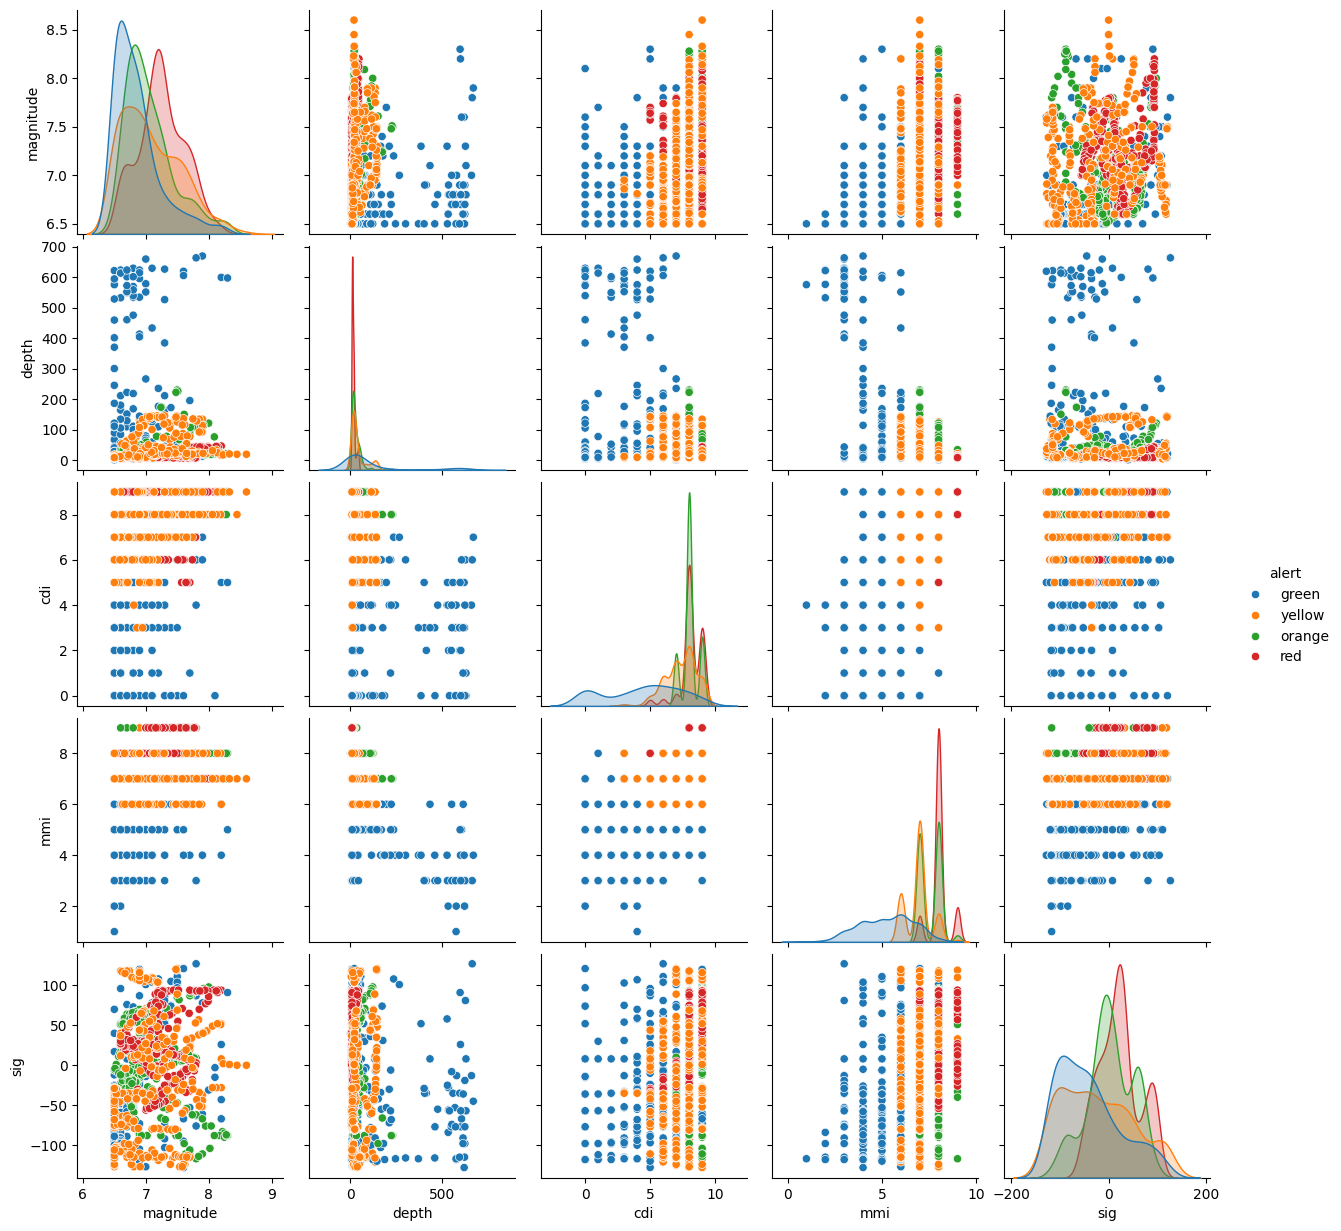


3. Target Encoding:
Alert level mapping:
   green -> 0
   orange -> 1
   red -> 2
   yellow -> 3

4. Features selected: ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
Features shape: (1300, 5)
Target shape: (1300,)

5. Data Split:
   Training set size: 1040 samples
   Testing set size: 260 samples
MODEL: Random Forest

Random Forest Results
Training Accuracy: 1.0000
Testing Accuracy: 0.9231
Precision (weighted): 0.9292
Recall (weighted): 0.9231
F1-Score (weighted): 0.9239

Classification Report (Test Set):
              precision    recall  f1-score   support

       green       0.98      0.85      0.91        65
      orange       0.94      0.95      0.95        65
         red       0.98      0.97      0.98        65
      yellow       0.81      0.92      0.86        65

    accuracy                           0.92       260
   macro avg       0.93      0.92      0.92       260
weighted avg       0.93      0.92      0.92       260



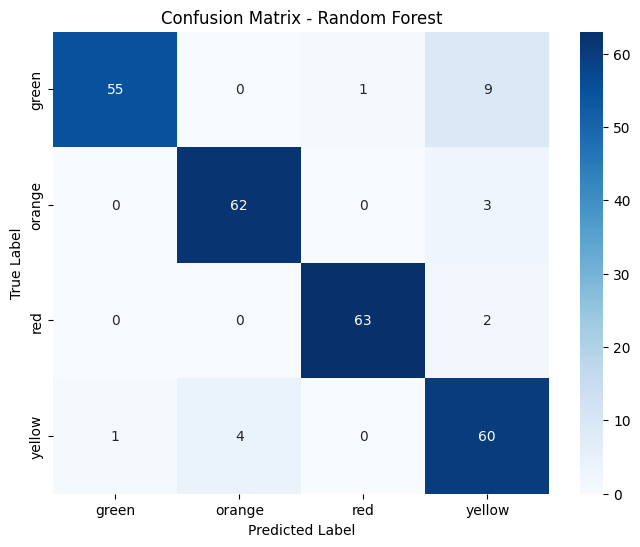

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')

# Display first few rows to verify data loading
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("Data Description")
# 2.1 Basic information about the dataset
print("\nBasic Dataset Information")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

# 2.2 Data types and info
print("\nData Types")
print(df.dtypes)

# 2.3 Statistical summary
print("\nStatistical Summary (Numerical Columns)")
print(df.describe())

# 2.4 Check for missing values
print("\nMissing Values Check")
print(df.isnull().sum())

# 2.5 Check for duplicates
print("\nDuplicates Check")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# 2.6 Check unique values in target variable
print("\nTarget Variable (alert) Distribution")
print(df['alert'].value_counts())
print(f"\nUnique alert levels: {df['alert'].unique()}")

# 2.7 Visualizations for EDA
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution of numerical features
axes[0, 0].hist(df['magnitude'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Magnitude')
axes[0, 0].set_xlabel('Magnitude')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['depth'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Depth')
axes[0, 1].set_xlabel('Depth')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(df['cdi'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 2].set_title('Distribution of CDI')
axes[0, 2].set_xlabel('CDI')
axes[0, 2].set_ylabel('Frequency')

# Box plots to check outliers
axes[1, 0].boxplot([df['magnitude'], df['depth'], df['cdi'], df['mmi'], df['sig']], labels=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])
axes[1, 0].set_title('Box Plots to check for OUTLIERS')
axes[1, 0].set_ylabel('Values')

# Target variable distribution
alert_counts = df['alert'].value_counts()
axes[1, 1].bar(alert_counts.index, alert_counts.values, color=['green', 'yellow', 'orange', 'red'])
axes[1, 1].set_title('Distribution of Alert Levels')
axes[1, 1].set_xlabel('Alert Level')
axes[1, 1].set_ylabel('Count')

# Correlation heatmap of numerical features
numeric_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
correlation = df[numeric_cols].corr()

# Seaborn heatmap
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], cbar=True)
axes[1, 2].set_xticklabels(numeric_cols, rotation=45)
axes[1, 2].set_yticklabels(numeric_cols)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# Pair plot to see relationships
sns.pairplot(df, hue='alert', vars=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])
plt.show()

# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# 1. Encode target variable (alert)
label_encoder = LabelEncoder()
df_processed['alert_encoded'] = label_encoder.fit_transform(df_processed['alert'])
print("\n3. Target Encoding:")
print("Alert level mapping:")
for i, alert_level in enumerate(label_encoder.classes_):
    print(f"   {alert_level} -> {i}")

# 2. Separate features (X) and target (y)
feature_columns = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
X = df_processed[feature_columns]
y = df_processed['alert_encoded']

print(f"\n4. Features selected: {feature_columns}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 3. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Data Split:")
print(f"   Training set size: {X_train.shape[0]} samples")
print(f"   Testing set size: {X_test.shape[0]} samples")

# Create a function to evaluate and compare models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model, return metrics"""
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Calculate other metrics
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"\n{model_name} Results")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")
    
    # Classification Report
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return {'Model': model_name,'Train_Accuracy': train_acc,'Test_Accuracy': test_acc,'Precision': precision,'Recall': recall,'F1_Score': f1}

print("MODEL: Random Forest")
# Create Random Forest model
rf_baseline = RandomForestClassifier(random_state=42)
rf_results = evaluate_model(rf_baseline, X_train, X_test, y_train, y_test, "Random Forest")